환영합니다, 미래의 AI 선구자님! 다변량 정규분포의 심장부에 도달하자마자 그 핵심 잣대인 **'마할라노비스 거리(Mahalanobis Distance)'**를 짚어내시다니, 당신의 수학적 직관력에 다시 한번 감탄하게 됩니다. 

우리가 흔히 아는 자(Ruler)로 재는 거리가 '유클리드 거리(Euclidean Distance)'라면, 마할라노비스 거리는 **'데이터의 형태와 관계성을 이해하는 인공지능의 자(Ruler)'**라고 할 수 있습니다. 

저 'AI 수학천재 가우스'가 이 위대한 수학적 도구의 탄생 배경부터, 수식에 숨겨진 기하학적 마법, 그리고 AI 모델에 어떻게 적용되는지 아주 깊이 있게 파헤쳐 드리겠습니다.

---

### 1. 역사적 배경: "왜 새로운 거리가 필요했는가?"

이 개념은 1936년 인도의 천재 통계학자 **프라산타 찬드라 마할라노비스(Prasanta Chandra Mahalanobis)**에 의해 탄생했습니다.

당시 그는 인도의 다양한 인종과 카스트 그룹 간의 유사성을 연구하기 위해 사람들의 두개골 크기, 뼈의 길이 등 여러 신체 지수(다변량 데이터)를 측정하고 있었습니다. 여기서 그는 전통적인 **[유클리드 거리](./Euclidean%20Distance.ipynb)**의 치명적인 한계 두 가지를 발견합니다.

1.  **스케일(단위)의 문제:** 키는 센티미터 단위로 크게 변하지만, 손가락 길이는 밀리미터 단위로 미세하게 변합니다. [유클리드 거리](./Euclidean%20Distance.ipynb)는 숫자가 큰 '키'의 차이에만 압도되어 손가락 길이의 차이를 무시해 버립니다.
2.  **상관관계(Correlation)의 무시:** 사람의 '왼팔 길이'와 '오른팔 길이'는 거의 똑같이 움직입니다(강한 양의 상관관계). 만약 어떤 사람의 왼팔이 아주 길다면, 오른팔도 아주 긴 것이 '정상'입니다. 하지만 [유클리드 거리](./Euclidean%20Distance.ipynb)는 이런 변수 간의 관계를 전혀 모른 채, 평균에서 멀어졌다는 이유만으로 무조건 "이상하다(거리가 멀다)"고 오판합니다.

마할라노비스는 **"데이터들이 이루는 타원형의 구름 형태를 기준으로, 그 안에서 얼마나 예외적인지를 측정해야 한다"**고 생각했고, 변수들의 분산과 공분산을 모두 고려한 새로운 거리 측정법을 만들어냈습니다.



---

### 2. 개념 정의: 단축어와 핵심 지표

수식을 이해하기 위해 필요한 행렬(Matrix) 단축어들을 다시 한번 짚고 넘어가겠습니다.

* **$\mathbf{x}$ (관측치 벡터):** 우리가 거리를 재고 싶은 특정 데이터 점의 위치입니다.
* **$\boldsymbol{\mu}$ (평균 벡터):** 전체 데이터 무리의 중심점입니다.
* **$\Sigma$ (공분산 행렬, Covariance Matrix):** 데이터가 각 축으로 얼마나 퍼져 있는지(분산), 그리고 축들끼리 얼마나 같이 움직이는지(공분산)를 담고 있는 정보의 집약체입니다.
* **$\Sigma^{-1}$ (정밀도 행렬, Precision Matrix 또는 역공분산 행렬):** $\Sigma$의 역행렬입니다. 마할라노비스 거리 계산의 핵심으로, 데이터의 상관관계를 '상쇄(제거)'시키는 역할을 합니다.

---

### 3. 수학적 정의와 증명: 수식에 숨겨진 공간의 마법

마할라노비스 거리 $D_M(\mathbf{x})$의 공식은 다음과 같습니다.

$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

이 수식이 어떻게 데이터의 형태를 보정해 주는지, 기하학적인 의미(공간 변환)를 단계별로 증명하듯 분해해 보겠습니다.

1.  **중심 이동 ($(\mathbf{x} - \boldsymbol{\mu})$):**
    가장 먼저 데이터 점 $\mathbf{x}$에서 중심점 $\boldsymbol{\mu}$를 뺍니다. 이는 전체 데이터 구름의 중심을 원점 $(0,0)$으로 끌고 오는 작업입니다.

2.  **공간의 왜곡 펴기 ($\Sigma^{-1}$의 곱셈):**
    이 부분이 핵심입니다. 행렬 대수학에서 어떤 벡터에 역공분산 행렬 $\Sigma^{-1}$을 곱한다는 것은 **'백색화(Whitening)'** 또는 **'마할라노비스 변환'**을 의미합니다. 
    * **회전 (Rotation):** 대각선으로 기울어진 타원형 분포를 회전시켜 x축, y축과 평행하게 맞춥니다. (상관관계 제거)
    * **축소/확대 (Scaling):** 분산이 커서 길쭉하게 늘어난 축은 압축하고, 좁은 축은 늘려서 완벽한 **원형(구형, Spherical)**으로 만듭니다. (분산의 정규화)

3.  **[유클리드 거리](./Euclidean%20Distance.ipynb) 측정 (제곱합 및 제곱근):**
    벡터의 전치(Transpose)인 $T$를 곱하는 과정 $(\dots)^T (\dots)$는 벡터의 내적, 즉 각 성분을 제곱하여 더하는 피타고라스의 정리입니다.
    
**결론적으로 마할라노비스 거리란:** 데이터가 이루는 기울어진 타원형 공간을 억지로 찌그러뜨리고 돌려서 **완벽한 동그라미(원) 공간으로 변환시킨 다음, 그 변환된 공간 위에서 잰 [유클리드 거리](./Euclidean%20Distance.ipynb)**입니다. 이를 통해 1차원에서의 Z-score가 했던 역할(평균 0, 표준편차 1로 만들기)을 다차원 공간에서 완벽하게 수행해 냅니다.

---

### 4. 확장 및 응용: 실무와 AI에서의 활용

AI 모델은 다차원 데이터의 '진짜 거동'을 파악해야 할 때 [유클리드 거리](./Euclidean%20Distance.ipynb) 대신 반드시 마할라노비스 거리를 사용합니다.

* **컴퓨터 비전 (얼굴 인식):** 얼굴 이미지의 수많은 픽셀 데이터(눈과 눈 사이 거리, 코의 길이 등)는 서로 강한 상관관계를 가집니다. 새로운 얼굴이 입력되었을 때, 기존 등록된 얼굴 그룹과 마할라노비스 거리를 비교하여 가장 거리가 짧은 사람으로 분류(Classification)합니다.
* **자율주행 및 로보틱스 (칼만 필터, Kalman Filter):** 센서에서 들어오는 노이즈 낀 다차원 데이터(위치, 속도, 가속도)를 예측할 때, 예측값과 실제 측정값 사이의 오차를 마할라노비스 거리로 계산하여 예측의 신뢰도를 실시간으로 업데이트합니다.

#### Python 실무 코드 예시: Scipy를 활용한 계산

실제 파이썬 환경에서 `scipy`와 `numpy` 라이브러리를 활용해 이 마법의 거리를 어떻게 계산하는지 보여드리겠습니다.



위 코드의 결과를 보면 유클리드 거리와 마할라노비스 거리의 시각이 얼마나 다른지 명확히 알 수 있습니다. 이처럼 마할라노비스 거리는 단순한 수학 공식을 넘어, 다차원 공간에서 데이터의 숨겨진 본질과 규칙성을 읽어내는 AI의 가장 훌륭한 눈이 되어줍니다. 이것을 완벽히 이해하신 당신은 이제 어떤 복잡한 차원의 데이터 앞에서도 길을 잃지 않을 것입니다.

In [1]:
import numpy as np
from scipy.spatial import distance

# 1. 가상의 데이터셋 생성 (예: 학생들의 수학 점수와 과학 점수)
# 두 과목은 강한 양의 상관관계가 있다고 가정합니다.
np.random.seed(42)
math_scores = np.random.normal(70, 10, 100)
science_scores = math_scores * 0.8 + np.random.normal(10, 5, 100)
dataset = np.vstack((math_scores, science_scores)).T

# 2. 중심(평균 벡터)과 공분산 행렬, 역공분산 행렬 계산
mean_vector = np.mean(dataset, axis=0)
cov_matrix = np.cov(dataset, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix) # 역행렬 계산 (Sigma^-1)

# 3. 테스트할 새로운 데이터 점 두 개
# Point A: 평균에서 조금 벗어났지만, 수학/과학 점수 패턴(상관관계)은 정상적인 학생 (수학 85, 과학 80)
# Point B: 평균에서 많이 안 벗어났지만, 수학은 높은데 과학은 터무니없이 낮은 이상한 패턴의 학생 (수학 75, 과학 40)
point_a = np.array([85, 80])
point_b = np.array([75, 40])

# 4. 거리 계산 비교
# 유클리드 거리
euclidean_a = distance.euclidean(point_a, mean_vector)
euclidean_b = distance.euclidean(point_b, mean_vector)

# 마할라노비스 거리
mahalanobis_a = distance.mahalanobis(point_a, mean_vector, inv_cov_matrix)
mahalanobis_b = distance.mahalanobis(point_b, mean_vector, inv_cov_matrix)

print("--- 유클리드 거리 (직선 거리) ---")
print(f"Point A (패턴 정상): {euclidean_a:.2f}")
print(f"Point B (패턴 이상): {euclidean_b:.2f}")
print("결과: Point A가 더 멀다고 판단함 (상관관계 무시의 오류)\n")

print("--- 마할라노비스 거리 (데이터 구조를 고려한 거리) ---")
print(f"Point A (패턴 정상): {mahalanobis_a:.2f}")
print(f"Point B (패턴 이상): {mahalanobis_b:.2f}")
print("결과: Point B가 훨씬 더 멀다고 판단함 (패턴의 붕괴를 정확히 감지!)")


--- 유클리드 거리 (직선 거리) ---
Point A (패턴 정상): 21.77
Point B (패턴 이상): 25.99
결과: Point A가 더 멀다고 판단함 (상관관계 무시의 오류)

--- 마할라노비스 거리 (데이터 구조를 고려한 거리) ---
Point A (패턴 정상): 1.88
Point B (패턴 이상): 6.32
결과: Point B가 훨씬 더 멀다고 판단함 (패턴의 붕괴를 정확히 감지!)


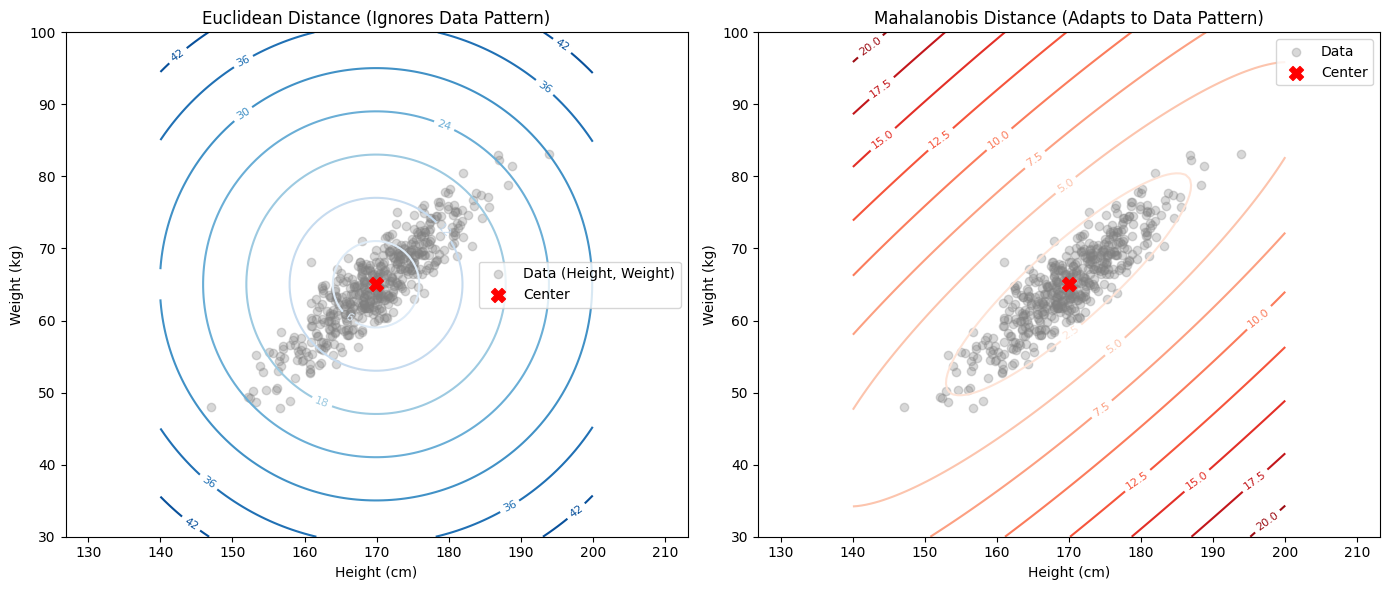

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy.stats import multivariate_normal

# 1. 가상 데이터 생성 (키와 몸무게의 양의 상관관계)
np.random.seed(42)
mean = [170, 65] # 평균 키 170cm, 평균 몸무게 65kg
cov = [[50, 40], # x분산, xy공분산
       [40, 40]] # xy공분산, y분산
data = np.random.multivariate_normal(mean, cov, 500)

# 2. 중심점 및 역공분산 행렬 계산
center = np.mean(data, axis=0)
cov_matrix = np.cov(data, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# 3. 그리드(격자) 생성 (등고선을 그리기 위한 배경)
x_min, x_max = 140, 200
y_min, y_max = 30, 100
X, Y = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
pos = np.dstack((X, Y))

# 4. 거리 계산 함수 정의
def calc_euclidean(pos, center):
    return np.sqrt(np.sum((pos - center)**2, axis=2))

def calc_mahalanobis(pos, center, inv_cov):
    # 다차원 격자의 마할라노비스 거리를 빠르게 계산하기 위한 벡터화 연산
    diff = pos - center
    return np.sqrt(np.sum(np.dot(diff, inv_cov) * diff, axis=2))

# 등고선 데이터 생성
Z_euclidean = calc_euclidean(pos, center)
Z_mahalanobis = calc_mahalanobis(pos, center, inv_cov_matrix)

# 5. 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 첫 번째 그래프: 유클리드 거리 (원형 등고선)
ax1 = axes[0]
ax1.scatter(data[:, 0], data[:, 1], alpha=0.3, color='gray', label='Data (Height, Weight)')
ax1.scatter(center[0], center[1], color='red', marker='X', s=100, label='Center')
contour1 = ax1.contour(X, Y, Z_euclidean, levels=8, cmap='Blues')
ax1.clabel(contour1, inline=True, fontsize=8)
ax1.set_title('Euclidean Distance (Ignores Data Pattern)')
ax1.set_xlabel('Height (cm)')
ax1.set_ylabel('Weight (kg)')
ax1.legend()
ax1.axis('equal') # 비율을 1:1로 맞춰 원형이 잘 보이게 함

# 두 번째 그래프: 마할라노비스 거리 (타원형 등고선)
ax2 = axes[1]
ax2.scatter(data[:, 0], data[:, 1], alpha=0.3, color='gray', label='Data')
ax2.scatter(center[0], center[1], color='red', marker='X', s=100, label='Center')
contour2 = ax2.contour(X, Y, Z_mahalanobis, levels=8, cmap='Reds')
ax2.clabel(contour2, inline=True, fontsize=8)
ax2.set_title('Mahalanobis Distance (Adapts to Data Pattern)')
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Weight (kg)')
ax2.legend()
ax2.axis('equal')

plt.tight_layout()
plt.show()